<img src="https://www.pucsp.br/sites/default/files/download/brasao-PUCSP-assinatura-principal-RGB.png" style="float:right;" width="150px">

# Ciências da Computação [》](https://www.pucsp.br/graduacao/ciencia-da-computacao)

## Inteligência Artificial

IA ML (Machine Learning, Aprendizagem de Máquina)

**Objetivo desta aula e LAB explorar os modelos de Redes Neurais Artificiais (ANN - Artificial Neural Network) com Scikit-Learn em Python, sobre os dados da Lego**

Inteligência Artificial - ML com Scikit-learn

PARTE II - LAB

### Dados (LEGO)

LEGO sets released from 1970 to 2022, including details on each set's theme, pieces, recommended age, retail price, and image.

https://mavenanalytics.io/data-playground/lego-sets


## TODO

LAB:
Isabela Groke Gomes, Caroline Guimarães Campos
EM DUPLAS (Pairing)<br>
Entrega amanhã (24 horas) em atividade no MS Teams
- Entregar o link do .ipynb no GitHub

- Baixar os dados
- Carregar em data frame Pandas
- Exibir visualmente os dados faltantes
- Organizar e limpar os dados
- Completar os kits de lego (Lego Sets) sem preço
   - Modelagem: Usando redes neurais artificial (ANN)
   - Scikit-learn
- Realizar análise e visualizações
   

Baixando dados do site, com o comando do Linux `wget` e o magic **!**

In [6]:
!wget https://maven-datasets.s3.amazonaws.com/LEGO+Sets/LEGO+Sets.zip

--2026-09-28 12:25:33--  https://maven-datasets.s3.amazonaws.com/LEGO+Sets/LEGO+Sets.zip
Resolving maven-datasets.s3.amazonaws.com (maven-datasets.s3.amazonaws.com)... 54.231.227.82, 16.15.199.91, 52.217.118.106, ...
Connecting to maven-datasets.s3.amazonaws.com (maven-datasets.s3.amazonaws.com)|54.231.227.82|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 536301 (524K) [application/zip]
Saving to: ‘LEGO+Sets.zip.1’

LEGO+Sets.zip.1     100%[===================>] 523.73K  --.-KB/s    in 0.07s   

2026-09-28 12:25:33 (7.05 MB/s) - ‘LEGO+Sets.zip.1’ saved [536301/536301]



Descompactando arquivo zip

In [7]:
!unzip *.zip

Archive:  LEGO+Sets.zip
replace lego_sets.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

Listando os arquivos na pasta atual

In [8]:
!ls -l

total 4904
-rw-r--r-- 1 root root 3936470 Jan  3  2024 lego_sets.csv
-rw-r--r-- 1 root root     532 Jan  3  2024 lego_sets_data_dictionary.csv
-rw-r--r-- 1 root root  536301 Jan  3  2024 LEGO+Sets.zip
-rw-r--r-- 1 root root  536301 Jan  3  2024 LEGO+Sets.zip.1
drwxr-xr-x 1 root root    4096 Sep 16 13:26 sample_data


Importando LIBs de EDA (Exploratory Data Analisys)


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


Carregando e visualizando dados

In [10]:
lego_df = pd.read_csv('lego_sets.csv')

lego_df.head()

,set_id,name,year,theme,subtheme,themeGroup,category,pieces,minifigs,agerange_min,US_retailPrice,bricksetURL,thumbnailURL,imageURL
0,1-8,Small house set,1970,Minitalia,NaN,Vintage,Normal,67.0,NaN,NaN,NaN,https://brickset.com/sets/1-8,https://images.brickset.com/sets/small/1-8.jpg,https://images.brickset.com/sets/images/1-8.jpg
1,2-8,Medium house set,1970,Minitalia,NaN,Vintage,Normal,109.0,NaN,NaN,NaN,https://brickset.com/sets/2-8,https://images.brickset.com/sets/small/2-8.jpg,https://images.brickset.com/sets/images/2-8.jpg
2,3-6,Medium house set,1970,Minitalia,NaN,Vintage,Normal,158.0,NaN,NaN,NaN,https://brickset.com/sets/3-6,https://images.brickset.com/sets/small/3-6.jpg,https://images.brickset.com/sets/images/3-6.jpg
3,4-4,Large house set,1970,Minitalia,NaN,Vintage,Normal,233.0,NaN,NaN,NaN,https://brickset.com/sets/4-4,https://images.brickset.com/sets/small/4-4.jpg,https://images.brickset.com/sets/images/4-4.jpg
4,4-6,Mini House and Vehicles,1970,Samsonite,Model Maker,Vintage,Normal,NaN,NaN,NaN,NaN,https://brickset.com/sets/4-6,NaN,NaN


Buscando os valores faltantes (nulls)

In [11]:
# show missing values
lego_df.isnull().sum()

,0
set_id,0
name,0
year,0
theme,0
subtheme,3556
themeGroup,2
category,0
pieces,3924
minifigs,10058
agerange_min,11670


Visualizando valores faltantes (nulls)

<Axes: >

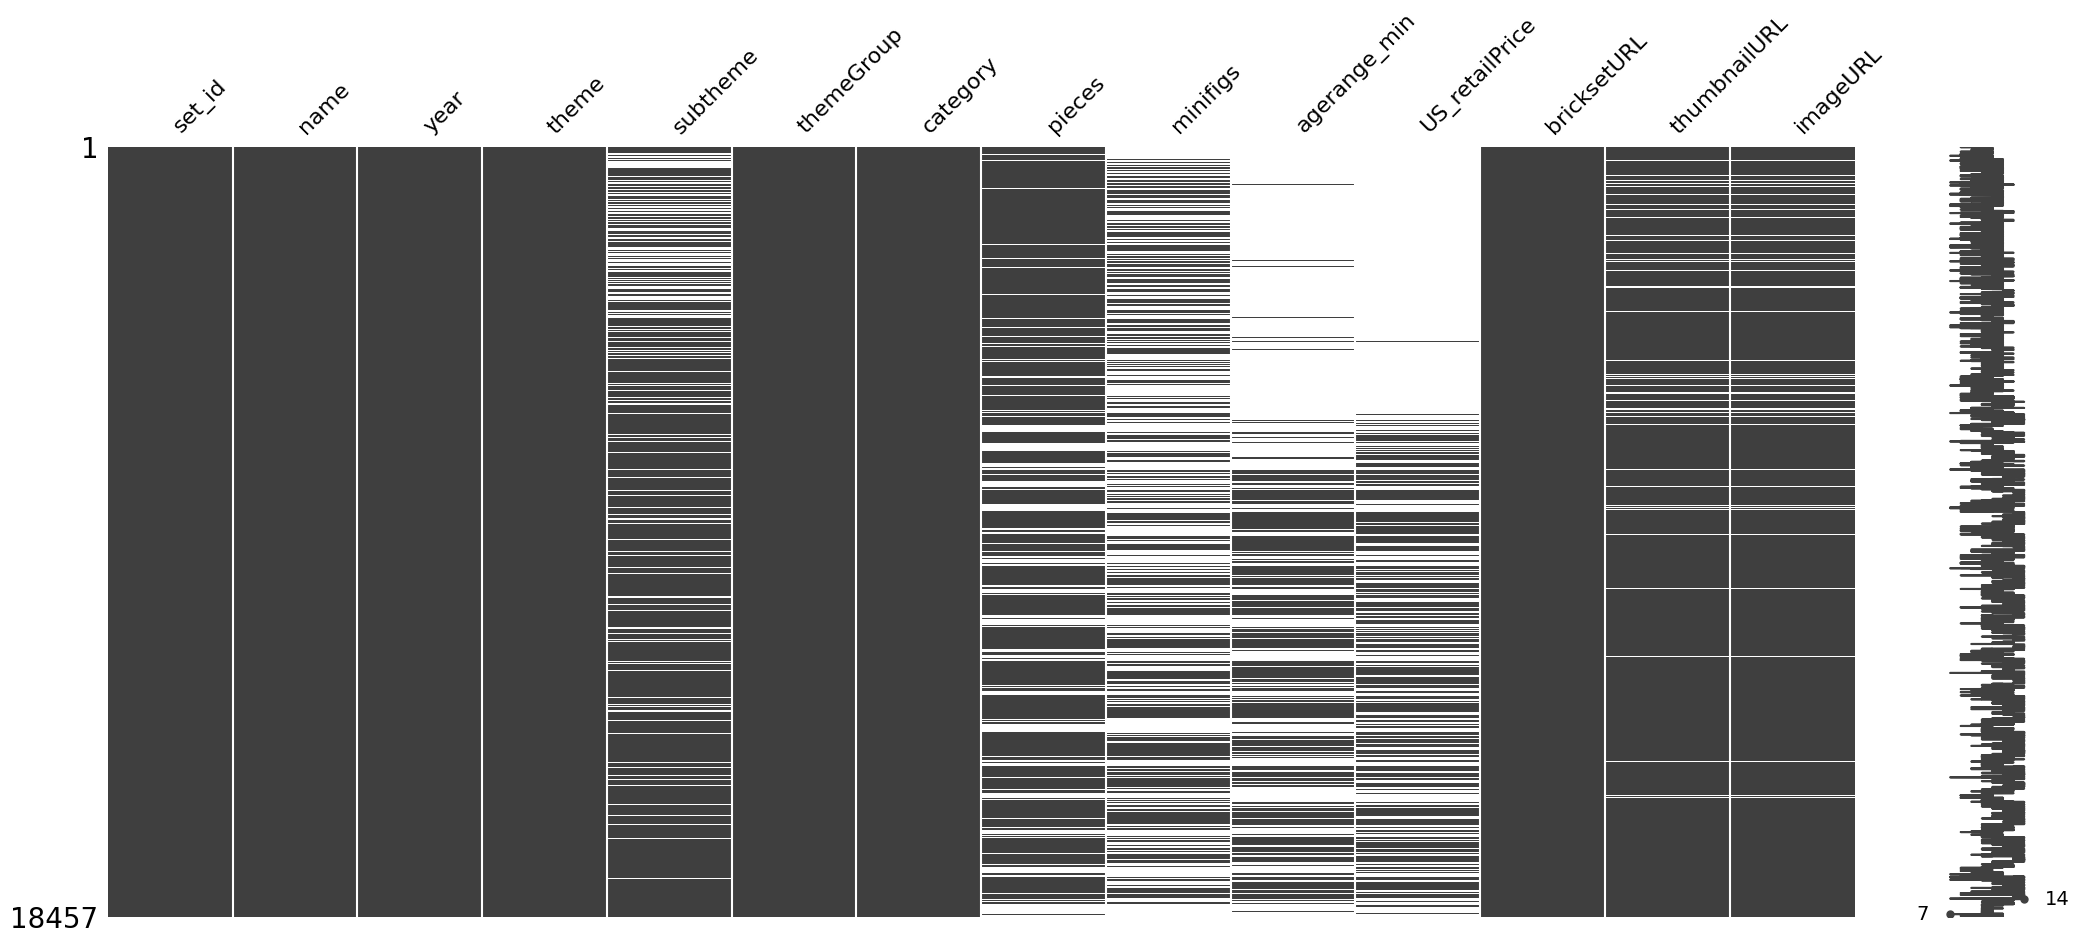

In [12]:
#Visualize missing values
msno.matrix(lego_df)


<Axes: >

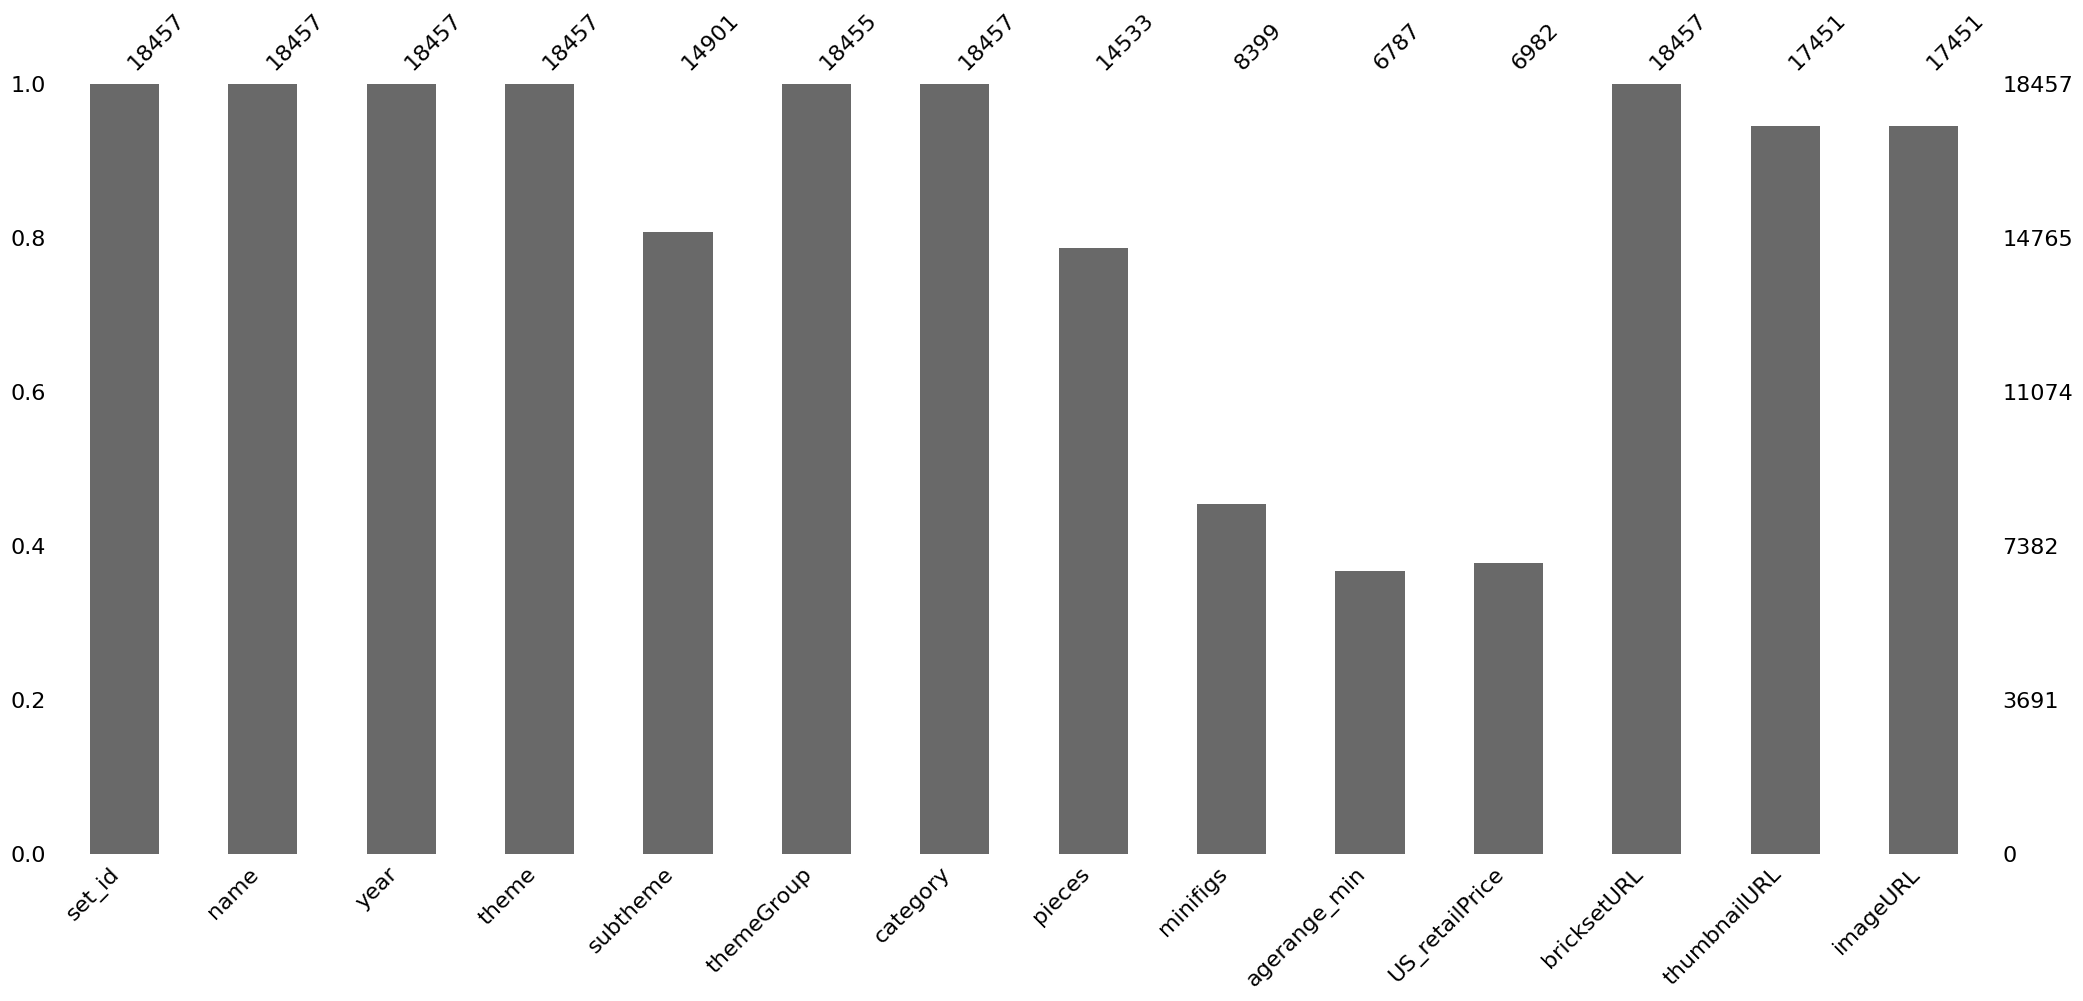

In [13]:
msno.bar(lego_df)


<Axes: >

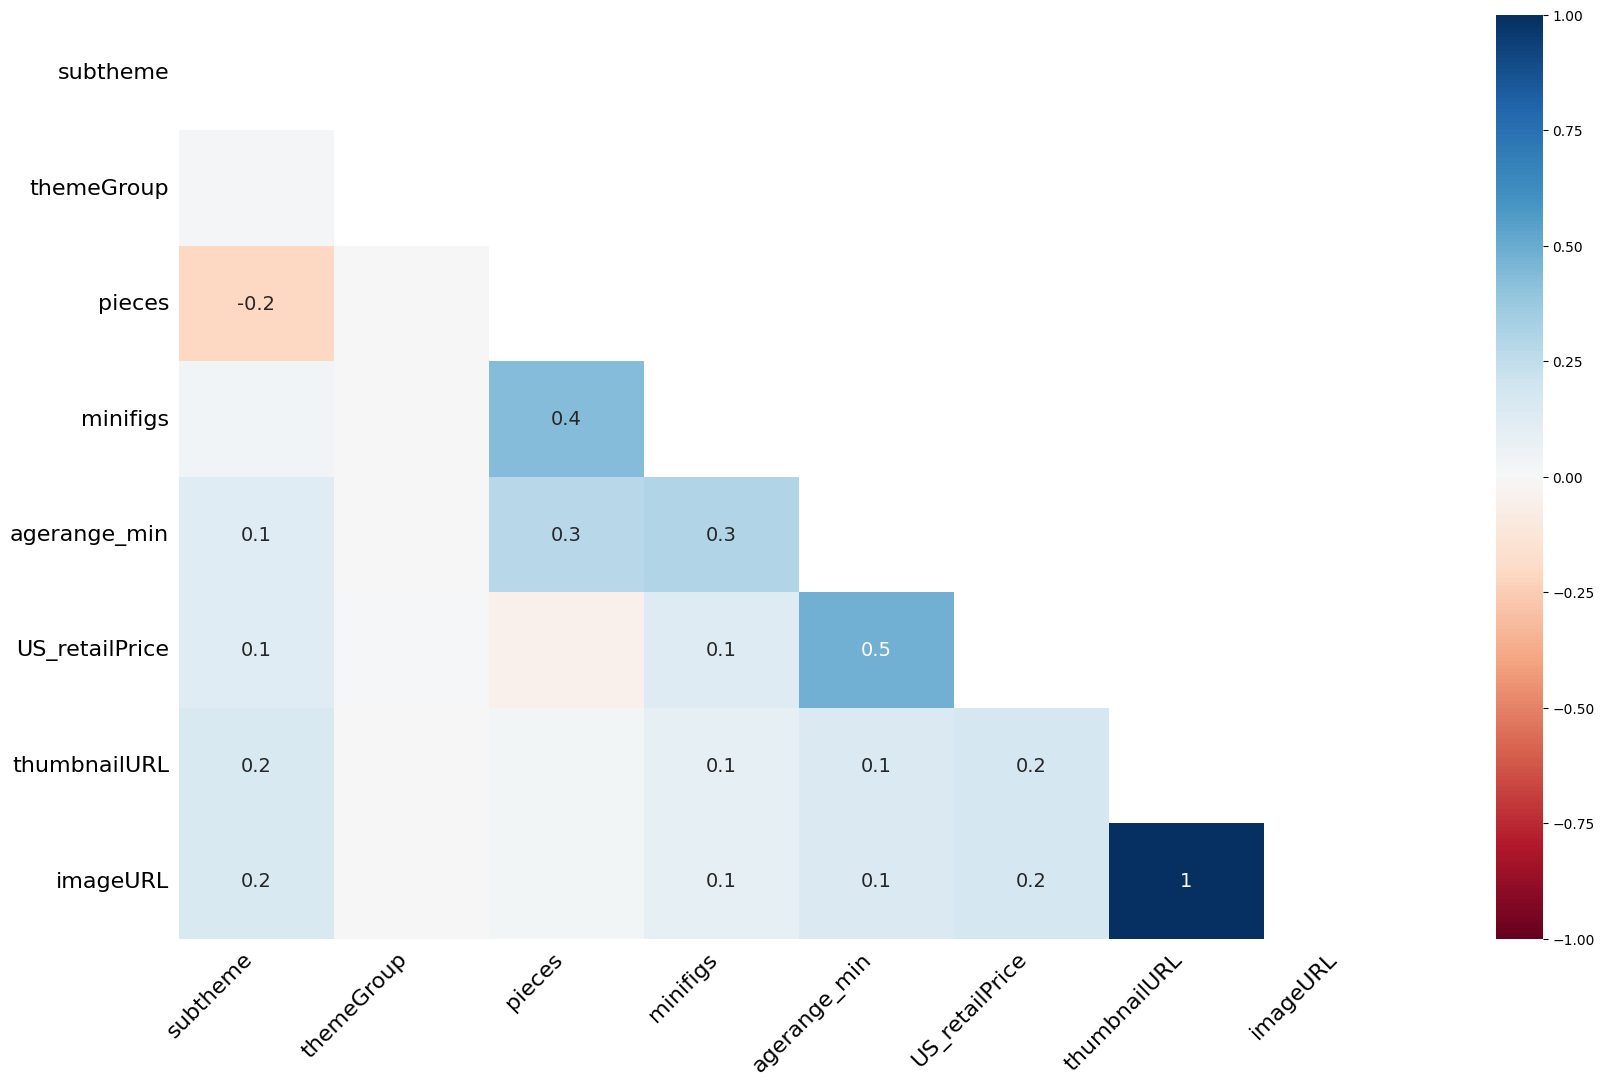

In [14]:
msno.heatmap(lego_df)


Atividade: Criar uma coluna nova `price` e completar usando o modelo de redes neurais do Scikit-Learn (ANN), todos os conjuntos de leve devem ter preço.

Quais as colunas importantes para prever o preço??

**Cria a coluna `price`**

In [17]:
lego_df['price'] = lego_df['US_retailPrice']
lego_df.columns

Index(['set_id', 'name', 'year', 'theme', 'subtheme', 'themeGroup', 'category',
       'pieces', 'minifigs', 'agerange_min', 'US_retailPrice', 'bricksetURL',
       'thumbnailURL', 'imageURL', 'price'],
      dtype='object')

 **Bibliotecas da ANN**

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

Colunas que serão utilizadas para preencher a coluna 'price'

In [40]:
features = ['year','theme','subtheme','themeGroup','category','pieces','minifigs','agerange_min']
target = 'price'

X.head()

,year,theme,subtheme,themeGroup,category,pieces,minifigs,agerange_min
0,1970,Minitalia,NaN,Vintage,Normal,67.0,NaN,NaN
1,1970,Minitalia,NaN,Vintage,Normal,109.0,NaN,NaN
2,1970,Minitalia,NaN,Vintage,Normal,158.0,NaN,NaN
3,1970,Minitalia,NaN,Vintage,Normal,233.0,NaN,NaN
4,1970,Samsonite,Model Maker,Vintage,Normal,NaN,NaN,NaN


Separar os dados que possuem preço

In [24]:
dados_com_preco = lego_df[lego_df['price'].notna()].copy()
dados_sem_preco = lego_df[lego_df['price'].isna()].copy()

print("Kits com preço:", len(dados_com_preco))
print("Kits sem preço:", len(dados_sem_preco))

Kits com preço: 6982
Kits sem preço: 11475


**Pré-processamento dos dados**

Antes do treinamento da ANN, os dados precisam ser preparados. Os valores ausentes das variáveis numéricas são preenchidos utilizando a mediana, enquanto os valores ausentes das variáveis categóricas são preenchidos utilizando a categoria mais frequente.

As variáveis categóricas são transformadas em variáveis numéricas por meio do One-Hot Encoding. As variáveis numéricas também são padronizadas para facilitar o treinamento da rede neural.

In [26]:
X_model = dados_com_preco[features]
y_model = dados_com_preco[target]

colunas_numericas = ['year','pieces','minifigs','agerange_min']
colunas_categoricas = ['theme','subtheme','themeGroup','category']

preprocessamento = ColumnTransformer(
    transformers=[
        (
            'numericas',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]),
            colunas_numericas
        ),
        (
            'categoricas',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))
            ]),
            colunas_categoricas
        )
    ]
)

Separa treinamento de teste

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.20,
    random_state=42
)

print("Dados de treinamento:", X_train.shape)
print("Dados de teste:", X_test.shape)

Dados de treinamento: (5585, 8)
Dados de teste: (1397, 8)


rede neural artificial — ANN

In [28]:
ann = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    random_state=42
)

modelo = Pipeline([
    ('preprocessamento', preprocessamento),
    ('ann', ann)
])

modelo.fit(X_train, y_train)

Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(transformers=[('numericas',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'pieces', 'minifigs',
                                                   'agerange_min']),
                                                 ('categoricas',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['theme', 'subtheme',
                                                   'themeGroup',
                                                   'category'])])),
                ('ann',
                 MLPRegressor(early_stopping=True, hidden_layer_sizes=(64, 32),
                              max_iter=500, random_state=42))])

**Avaliação do desempenho da ANN**

O modelo é avaliado comparando os preços reais e previstos por meio das métricas MAE, RMSE e R².

In [41]:
y_pred = modelo.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"R²: {r2:.4f}")

MAE: $5.78
RMSE: $14.29
R²: 0.9361


Visualizar preço real × preço previsto

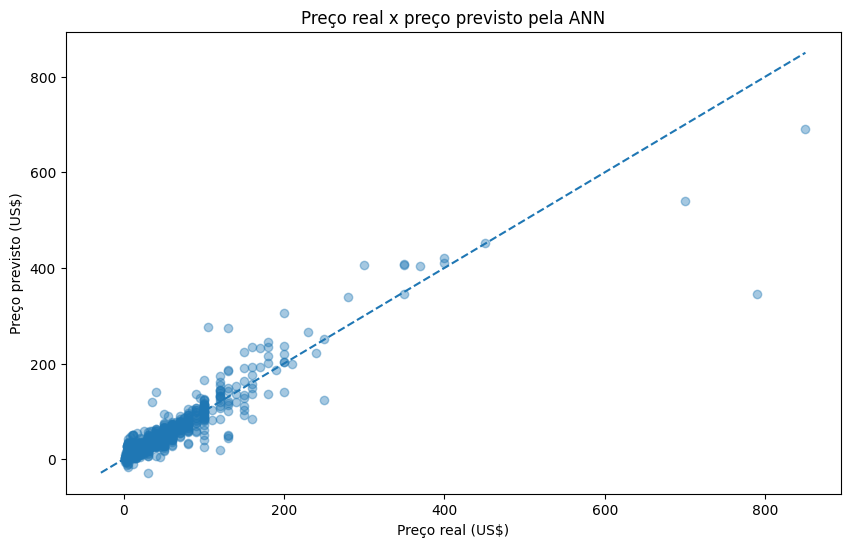

In [30]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.4)

plt.xlabel('Preço real (US$)')
plt.ylabel('Preço previsto (US$)')
plt.title('Preço real x preço previsto pela ANN')

limite_min = min(y_test.min(), y_pred.min())
limite_max = max(y_test.max(), y_pred.max())

plt.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    linestyle='--'
)

plt.show()

Colunas mais importantes

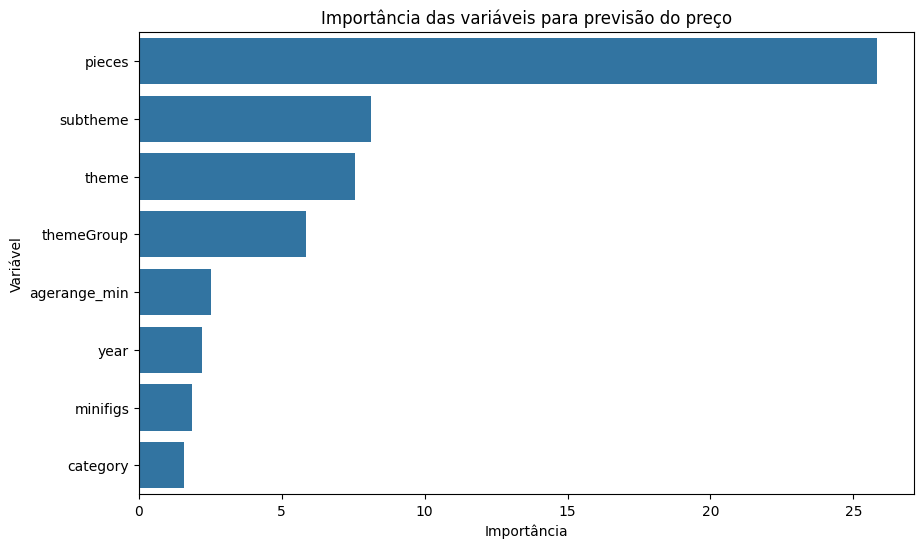

In [32]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importancias_df,
    x='importance',
    y='feature'
)

plt.title('Importância das variáveis para previsão do preço')
plt.xlabel('Importância')
plt.ylabel('Variável')

plt.show()

Treino

In [33]:
modelo.fit(
    dados_com_preco[features],
    dados_com_preco['price']
)

Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(transformers=[('numericas',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'pieces', 'minifigs',
                                                   'agerange_min']),
                                                 ('categoricas',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['theme', 'subtheme',
                                                   'themeGroup',
                                                   'category'])])),
                ('ann',
                 MLPRegressor(early_stopping=True, hidden_layer_sizes=(64, 32),
                              max_iter=500, random_state=42))])

prever preços

In [34]:
precos_previstos = modelo.predict(
    dados_sem_preco[features]
)

lego_df.loc[
    lego_df['price'].isna(),
    'price'
] = precos_previstos

In [35]:
print("Preços faltantes após a ANN:")
print(lego_df['price'].isna().sum())

Preços faltantes após a ANN:
0


In [36]:
precos_estimados = lego_df[
    lego_df['US_retailPrice'].isna()
][[
    'set_id',
    'name',
    'year',
    'theme',
    'pieces',
    'minifigs',
    'price'
]].copy()

precos_estimados.head(20)

,set_id,name,year,theme,pieces,minifigs,price
0,1-8,Small house set,1970,Minitalia,67.0,NaN,-35.463067
1,2-8,Medium house set,1970,Minitalia,109.0,NaN,-33.604522
2,3-6,Medium house set,1970,Minitalia,158.0,NaN,-31.430871
3,4-4,Large house set,1970,Minitalia,233.0,NaN,-27.970441
4,4-6,Mini House and Vehicles,1970,Samsonite,NaN,NaN,-22.220861
5,078-1,Roadway Base Plate 50X50,1970,Samsonite,1.0,NaN,-30.452583
6,104-1,4.5V Replacement Motor,1970,Trains,1.0,NaN,-0.339714
7,126-1,Steam Locomotive (Push),1970,Trains,60.0,NaN,2.183674
8,157-3,4 Car Auto Transport,1970,Samsonite,65.0,NaN,-27.666236
9,242-4,Big Model Book,1970,Books,NaN,NaN,7.756783


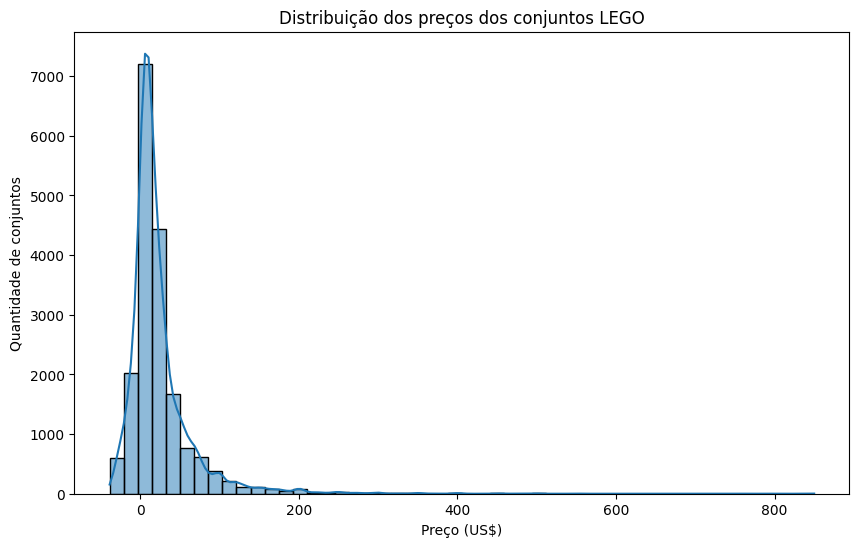

In [39]:
plt.figure(figsize=(10, 6))

sns.histplot(
    lego_df['price'],
    bins=50,
    kde=True
)

plt.title('Distribuição dos preços dos conjuntos LEGO')
plt.xlabel('Preço (US$)')
plt.ylabel('Quantidade de conjuntos')

plt.show()